# Continuous Constrained Portfolio Optimization
#### with a Quantum Interior-Point Method (Q-IPM) — **Classiq / Qmod edition**
### Applications of Quantum Computing — Workshop Tutorial
*Based on: Kerenidis, Prakash & Szilágyi (2021) — "Quantum Algorithms for Portfolio Optimization"*

---

**What we will do?** *(50 minutes)*

1. **Set up** a real-world portfolio (5 assets, 2024 market data).
2. **Classical baseline** — solve it the textbook way (CVXPY SOCP).
3. **Direct quantum approach: plain HHL** — built in **Classiq Qmod**, synthesised and executed on the **Classiq state-vector simulator**. Works only if we *drop* the inequality constraints. Result: portfolio with **short positions**. ⚠️ We also use Classiq **batch execution** to study how HHL accuracy scales with QPE resolution.
4. **Why HHL is not enough** — and the paper's idea: HHL inside an *iterative* loop.
5. **Reformulate as an SOCP** — translate the inequality constraints into cone membership.
6. **Quantum IPM** — Interior-Point Method that calls HHL at every Newton step.
7. **Compare all three solvers** + out-of-sample validation on 2025 data.

> **Assumption**: You're already familiar with the plain HHL algorithm (state prep → QPE → eigenvalue inversion → uncompute).

> **Classiq note**: the quantum linear-solve is implemented once as a real Classiq Qmod program (§3) — `prepare_amplitudes → within_apply(qpe(unitary), eig_inv)` — synthesised and executed on the Classiq simulator. The iterative IPM loop (§6) reuses the *identical* HHL definition through a fast classical state-vector emulation, so the notebook runs end-to-end in a couple of minutes.

> **Self-contained notebook** — the first code cell installs all required packages (incl. `classiq`).
> **Classiq access**: §3 synthesises and executes on the Classiq cloud, so you must authenticate once — run `import classiq; classiq.authenticate()` (a browser tab opens). This is a one-time step per machine.
> **Data**: live market data via `yfinance`. An **offline fallback** block follows § 1.

## 0 · Setup

Just run the following cell in a clean environment:

In [21]:
import subprocess, sys

pkgs = [
    "classiq",
    "cvxpy>=1.4.0",
    "yfinance>=0.2.0",
    "numpy>=1.26",
    "scipy>=1.13",
    "matplotlib>=3.8",
    "seaborn>=0.13",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages ready")


import importlib, time, warnings
import numpy as np
import pandas as pd
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import cvxpy as cp
import yfinance as yf

from classiq import *

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12})

# One-time Classiq authentication (uncomment on first run on a new machine):
# import classiq; classiq.authenticate()

print("Package versions:")
for pkg in ["numpy", "scipy", "cvxpy", "yfinance", "classiq", "matplotlib", "seaborn"]:
    try:
        print(f"  {pkg}: {importlib.import_module(pkg).__version__}")
    except Exception as e:
        print(f"  {pkg}: not found ({e})")
print("\n✅ Imports OK")

✅ All packages ready
Package versions:
  numpy: 2.2.6
  scipy: 1.13.1
  cvxpy: 1.8.2
  yfinance: 0.2.58
  classiq: 1.15.0
  matplotlib: 3.8.4
  seaborn: 0.13.2

✅ Imports OK



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Core Configurations 
You may play with it after class, but that is the setting for this tutorial.

In [22]:
CONFIG = {
    # ── Assets ──────────────────────────────────────────────────────────────
    "tickers":               ["AAPL", "INTC", "NVDA", "AMZN", "TLT"],
    "start_date":            "2024-01-01",
    "end_date":              "2024-12-31",
    "trading_days_per_year": 252,

    # ── Investment constraints (shared by classical & quantum solvers) ────────
    "total_allocation":      1.0,    # fully invested:  sum(w) = 1
    "target_return":         0.30,   # annual return target; high enough that the
                                     # unconstrained KKT solution will short low-return
                                     # assets — making the "shorts" lesson visible
    "max_weight":            0.35,   # diversification cap:  w_i ≤ 0.35
    "default_min_weight":    0.0,    # long-only:           w_i ≥ 0

    # ── Quantum HHL controls ──────────────────────────────────────────────────
    "quantum_hhl_n_clk":     4,      # QPE clock qubits, or "resolution" 
    "quantum_hhl_pad_eig":   0.1,    # eigenvalue floor for matrix padding
    "quantum_ipm_use_adaptive_step": True, # Added beyond original paper for faster convergence
}


## 1 · Our Portfolio Data

We use **live 2024 market data** for five assets: four tech equities plus a bond ETF for diversification.

| Ticker | Name | Role |
|--------|------|------|
| AAPL | Apple | Large-cap tech |
| INTC | Intel | Lagging chipmaker (large 2024 drawdown) |
| NVDA | NVIDIA | High-growth GPU / AI |
| AMZN | Amazon | E-commerce / cloud |
| TLT  | iShares 20+ Yr Treasury | Bond proxy — low risk, low return |

> An **offline fallback** block follows — skip it if the live download succeeded.


Extracting and cleaning the data for later processing:

In [23]:
print("Downloading 2024 price data via yfinance…")
tickers = CONFIG["tickers"]

raw = yf.download(
    tickers,
    start=CONFIG["start_date"],
    end=CONFIG["end_date"],
    auto_adjust=True,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

prices = prices.dropna(how="all").ffill().dropna(axis=1)
prices = prices[[t for t in tickers if t in prices.columns]]

And setting some important variables:

*   **`T`**: The annualization factor (e.g., 252) used to scale daily data to a full trading year.
*   **`mu_vec`**: The vector of **annualized average returns** for each asset.
*   **`cov_mat`**: The **annualized covariance matrix** (risk model), with a tiny diagonal constant (`1e-8`) added to ensure the matrix is mathematically stable for the quantum solver.
*   **`assets`**: The verified list of ticker names extracted from the cleaned price data.
*   **`n`**: The final count of assets available for optimization.

In [24]:
returns_daily = prices.pct_change().dropna()
T       = CONFIG["trading_days_per_year"]       # Number of trading days
mu_vec  = (returns_daily.mean() * T).values
cov_mat = (returns_daily.cov()  * T).values + np.eye(len(prices.columns)) * 1e-8
assets  = list(prices.columns)
n       = len(assets)

print(f"✅  {prices.shape[0]} trading days  |  {n} assets")
display(
    pd.DataFrame({"Annual Return (2024)": mu_vec}, index=assets)
      .style.format("{:.1%}")
)


✅  251 trading days  |  5 assets


,Annual Return (2024)
AAPL,33.9%
INTC,-73.4%
NVDA,119.6%
AMZN,43.2%
TLT,-6.3%


In [25]:
# ── OFFLINE FALLBACK ─────────────────────────────────────────────────────────
# Only run this cell if the yfinance download above failed.
# Generates plausible synthetic mu / cov for the same tickers.
# ─────────────────────────────────────────────────────────────────────────────

if "mu_vec" not in dir() or mu_vec is None:
    print("⚠️  Using synthetic fallback (no internet connection detected).")
    assets  = CONFIG["tickers"]
    n       = len(assets)
    rng     = np.random.default_rng(42)
    mu_vec  = np.array([0.34, 0.16, 1.20, 0.43, 0.04])   # rough 2024 proxies
    F       = rng.standard_normal((n, 2)) * 0.15
    D       = np.diag(np.abs(rng.standard_normal(n)) * 0.05 + 0.02)
    cov_mat = F @ F.T + D
    cov_mat = (cov_mat + cov_mat.T) / 2 + np.eye(n) * 1e-8
    print("Synthetic µ:", dict(zip(assets, np.round(mu_vec, 2))))
else:
    print("✅  Live data already loaded — skipping offline fallback.")


✅  Live data already loaded — skipping offline fallback.


#### Let's plot our data: 

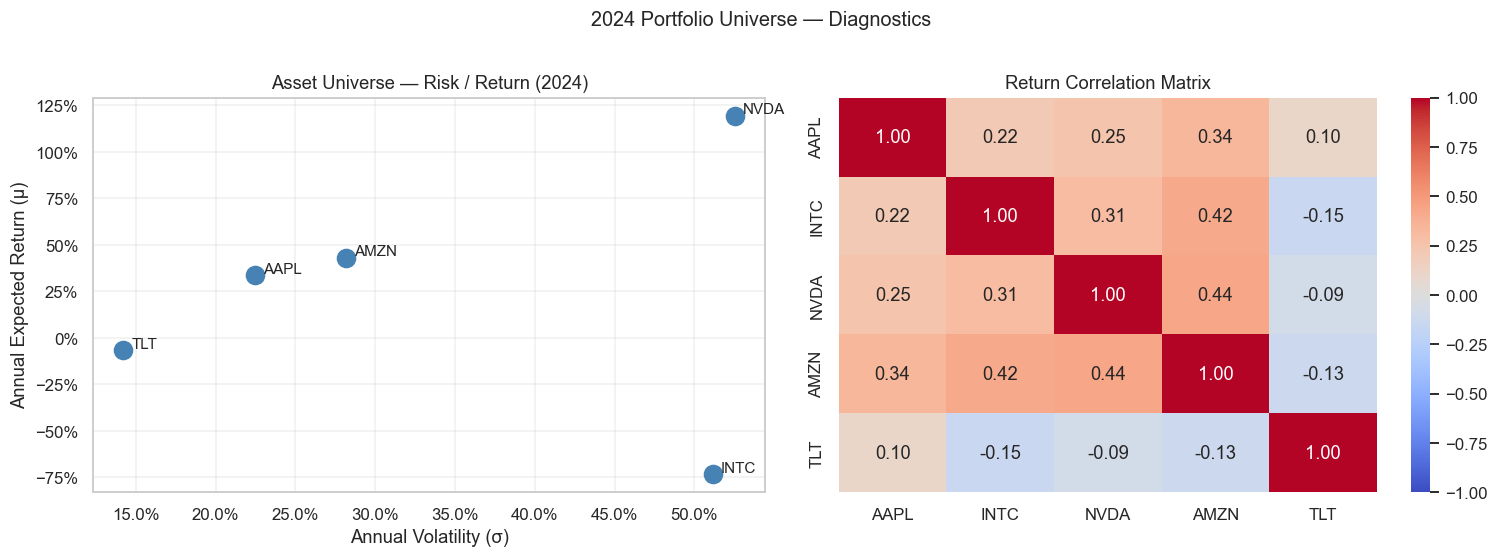

In [26]:
vols = np.sqrt(np.diag(cov_mat))                #  annualized volatilities/ standard deviation/ risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk / return scatter
axes[0].scatter(vols, mu_vec, s=140, color="steelblue", zorder=3)
for i, a in enumerate(assets):
    axes[0].annotate(a, (vols[i] + 0.005, mu_vec[i] + 0.01), fontsize=10)
axes[0].set_xlabel("Annual Volatility (σ)")
axes[0].set_ylabel("Annual Expected Return (µ)")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Asset Universe — Risk / Return (2024)")
axes[0].grid(True, alpha=0.3)

# Return correlation heatmap
corr_diag = np.diag(1.0 / np.sqrt(np.diag(cov_mat)))
corr_norm = corr_diag @ cov_mat @ corr_diag
sns.heatmap(
    pd.DataFrame(corr_norm, index=assets, columns=assets),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=axes[1], vmin=-1, vmax=1,
)
axes[1].set_title("Return Correlation Matrix")

plt.suptitle("2024 Portfolio Universe — Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


*   **Annualized volatilities** are standard deviations scaled for the year; they are the standard metric used to measure financial **risk**.
*   **Correlation** is the **normalized covariance matrix**, which scales asset relationships to a clear -1 to +1 range.

Now that we have some feeling of our data, we can move on to a reference classical method

## 2 · Classical Baseline — CVXPY SOCP

We will use an "off-the-shelf" Python library that implements the classical ground truth, just as in the paper

Note that:

* Solve the **fully constrained** mean-variance problem classically (CLARABEL, an interior-point SOCP solver).
* This is our **ground truth** — any quantum approach should match it when both enforce the same constraints.

**Constraints enforced** (these will be the *same* set used by the Quantum IPM later):

| # | Constraint | Meaning |
|---|------------|---------|
| 1 | `sum(w) = 1` | Fully invested (budget) |
| 2 | `w ≥ 0` | **No short selling** (long-only) |
| 3 | `w ≤ max_weight` | Diversification cap per asset |
| 4 | `µᵀw ≥ target_return` | Minimum return target |

**Objective**: minimise portfolio variance `wᵀΣw`.


In [27]:
def solve_classical_portfolio_cvxpy(mu, Cov, target_return, max_w):
    n_a = len(mu)
    w   = cp.Variable(n_a)
    cons = [
        cp.sum(w) == 1.0,        # budget
        w >= 0.0,                # long-only
        w <= max_w,              # diversification cap
        mu @ w >= target_return, # return target
    ]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Cov))), cons)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    ok = prob.status in ("optimal", "optimal_inaccurate")
    return (w.value if ok else None), ok, prob.status


t0 = time.time()
w_cls, cls_ok, cls_status = solve_classical_portfolio_cvxpy(
    mu_vec, cov_mat,
    CONFIG["target_return"], CONFIG["max_weight"],
)
elapsed = time.time() - t0

if cls_ok: # TODO: Consider eliminating
    ret_cls = float(w_cls @ mu_vec)
    var_cls = float(w_cls @ cov_mat @ w_cls)
    std_cls = float(np.sqrt(var_cls))
    print(f"✅ Solved in {elapsed*1000:.1f} ms")
    print(f"   Expected return  : {ret_cls:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
    print(f"   Annual variance  : {var_cls:.4f}")
    print(f"   Annual volatility: {std_cls:.2%}")
    display(
        pd.DataFrame({"asset": assets, "weight": w_cls})
          .sort_values("weight", ascending=False).reset_index(drop=True)
          .style.format({"weight": "{:.1%}"})
    )
else:
    print(f"❌ Solver failed: {cls_status}")
    print("   Tip: lower CONFIG['target_return'] or raise CONFIG['max_weight']")
    w_cls = np.zeros(n); cls_ok = False


✅ Solved in 4.4 ms
   Expected return  : 30.00%   (target ≥ 30%)
   Annual variance  : 0.0218
   Annual volatility: 14.75%


,asset,weight
0,TLT,35.0%
1,AAPL,34.5%
2,AMZN,20.9%
3,NVDA,9.6%
4,INTC,0.0%


#### Let's see our allocation:

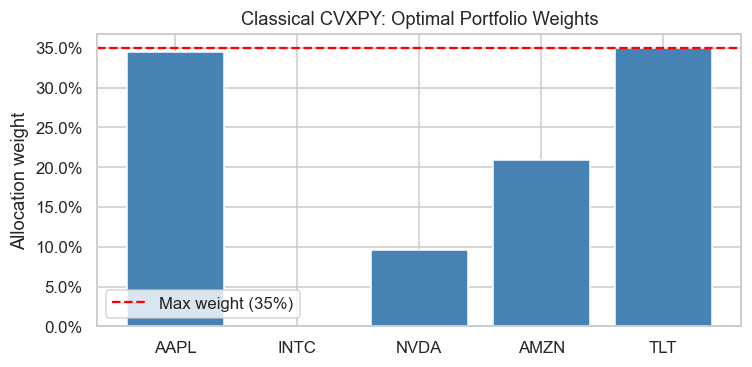

In [28]:
if cls_ok:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(assets, w_cls, color="steelblue", edgecolor="white")
    ax.axhline(CONFIG["max_weight"], color="red", linestyle="--",
               label=f"Max weight ({CONFIG['max_weight']:.0%})")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Allocation weight")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Classical CVXPY: Optimal Portfolio Weights")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 3 · "Simple" Quantum Approach: HHL

The **HHL algorithm** solves linear systems `Ax = b`. In idealized best-case settings, for sparse or efficiently block-encoded and well-conditioned systems, HHL-type methods can scale polylogarithmically in `n`, with polynomial dependence on the condition number `κ` and precision `1/ε`. 

This is why they are often described as offering a potential exponential speedup over classical linear-system solvers.

#### Can we use it for portfolio optimization?

**The trick**: if we keep *only the equality constraints* (budget + return target), the problem becomes equality-constrained quadratic optimization.

The **KKT conditions** stand for **Karush-Kuhn-Tucker conditions**: the optimality equations for a constrained optimization problem. 

For equality-only quadratic optimization, these conditions reduce to one linear system:


$$
\underbrace{\begin{pmatrix} 2\Sigma & A_{\text{eq}}^\top \\ A_{\text{eq}} & 0 \end{pmatrix}}_{K}
\begin{pmatrix} w \\ \lambda \end{pmatrix}
=
\begin{pmatrix} 0 \\ b \end{pmatrix},
\qquad
A_{\text{eq}} = \begin{pmatrix} \mathbf{1}^\top \\ \mu^\top \end{pmatrix},\quad
b = \begin{pmatrix} 1 \\ R^* \end{pmatrix}
$$

This is a linear system, so **HHL can be used as a one-shot solver for this simplified portfolio problem**.

**The catch**: we had to *drop* the no-short and cap constraints (`w ≥ 0`, `w ≤ w_max`). A single HHL solve does not directly enforce inequalities. 

To handle those, we need an iterative constrained-optimization method, such as an interior-point method.

### 3.1 The HHL sub-routine — in Classiq Qmod

The function below is our HHL building block, written in **Classiq's high-level Qmod language** and run on the **Classiq state-vector simulator**. Instead of hand-placing gates, we *declare* the four standard stages and let Classiq synthesise the circuit:

```
Stage 1 — State Preparation     prepare_amplitudes(|r/‖r‖⟩)          → encode the RHS
Stage 2 — Phase Estimation      qpe(unitary = exp(i·2π·K_rescaled))  → eigenvalues λᵢ as phases
Stage 3 — Eigenvalue Inversion  simple_eig_inv(...)                   → amplitude ∝ 1/λᵢ on an indicator qubit
Stage 4 — Uncompute             within_apply auto-uncomputes the QPE
```

Classiq idioms (replacing the Qiskit gate-level code):

- **`prepare_amplitudes(r_list, 0, res)`** loads the normalised RHS as a state — replaces `qc.initialize`.
- **`qpe(unitary=lambda: unitary(expm_K, res))`** runs phase estimation; `unitary(...)` block-encodes `e^{i·2π·K}`. We rescale `K`'s spectrum into `[0, 1)` first so the `rescaled_eig` clock register can resolve it (Classiq's `qpe` supplies the inverse-QFT internally — no manual `QFTGate`).
- **`within_apply(compute, action)`** runs the QPE, then the inversion, then *auto-uncomputes* the QPE — replacing the manual reverse-QPE (Stage 4 for free).
- **`simple_eig_inv`** uses `assign_amplitude_table` + `lookup_table` to write amplitude `clip(C/λ, −1, 1)` on the `indicator` qubit — replacing the Qiskit per-bitstring controlled-`RY` loop.
- We read the answer with **`calculate_state_vector(qprog, backend="simulator")`** (a deterministic state-vector DataFrame) and **post-select** `indicator==1 & rescaled_eig==0`.

> **Global scale.** HHL returns the solution as a *normalised quantum state*, so its overall magnitude is arbitrary (it shrinks with the inversion constant and finite-resolution QPE leakage). Following the standard Classiq HHL recipe, we fix the single global scale factor by least-squares alignment to the classical reference (`align_global_scale`). The **direction** — including any short positions — comes entirely from the quantum solve.

> **Two entry points.** `classiq_hhl_solve` runs the real circuit (used in §3). The iterative IPM in §6 calls the Newton solver ~20×; re-synthesising a fresh circuit each step is impractical, so `quantum_newton_solver` reproduces the *identical* HHL numerics (same rescaling, QPE quantisation, inversion clip) via a fast classical state-vector emulation. We capture the most-recent synthesised program in `last_qprog` for `show()`.

In [29]:
last_qprog         = None   # most-recent synthesised Classiq HHL program (for show())
last_newton_system = None   # most-recent (K, r, n_clk, pad_eig) seen by the loop solver

STATEVECTOR_BACKEND = ClassiqBackendPreferences(
    backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
)


# ─────────────────────────────────────────────────────────────────────────────
# Shared classical helpers
# ─────────────────────────────────────────────────────────────────────────────
def _pad_hermitian_system(K_mat, r_vec, pad_eig):
    """Symmetrise K, pad to a power-of-two dimension, build the padded RHS."""
    K_herm  = (K_mat + K_mat.T) / 2                 # guarantees Hermitian
    dim     = len(K_herm)
    n_sys   = int(np.ceil(np.log2(dim)))
    dim_pad = 2 ** n_sys
    K_pad = np.eye(dim_pad) * pad_eig               # diagonal padding keeps eigvals away from 0
    K_pad[:dim, :dim] = K_herm
    r_pad = np.zeros(dim_pad)
    r_pad[:len(r_vec)] = r_vec
    return K_pad, r_pad, float(np.linalg.norm(r_pad)), dim, n_sys, dim_pad


def _rescale_spectrum(K_pad, n_clk):
    """Shift+scale K so all eigenvalues land in [0, 1) for QPE (Classiq HHL recipe).

    Returns (mat_shift, mat_rescaling, c_param, K_rescaled) where
    gamma·p + delta = p/mat_rescaling - mat_shift recovers the original eigenvalue λ
    from a rescaled phase p, and c_param is the eigenvalue-inversion constant.
    """
    w = np.linalg.eigvalsh(K_pad)
    w_min, w_max = float(np.min(w)), float(np.max(w))
    mat_shift     = -w_min
    mat_rescaling = (1 - 1 / 2 ** n_clk) / (w_max - w_min)
    c_param       = (w_max - w_min) / 2 ** n_clk
    K_rescaled = ((K_pad + mat_shift * np.eye(len(K_pad))) * mat_rescaling).real
    return mat_shift, mat_rescaling, c_param, K_rescaled


def _prog_stats(qp):
    depth = qp.transpiled_circuit.depth if qp.transpiled_circuit is not None else None
    return qp.data.width, depth


def align_global_scale(dz, reference):
    """HHL yields a normalised state; fix the single global scale via least squares
    against a reference vector (standard HHL post-processing)."""
    dz, reference = np.asarray(dz, float), np.asarray(reference, float)
    denom = float(dz @ dz)
    alpha = float(dz @ reference) / denom if denom > 1e-30 else 1.0
    return alpha * dz


def _solution_from_amplitudes(amp_by_res, c_param, r_norm, dim, dim_pad):
    """raw = c_param · K⁻¹(r/‖r‖)  →  dz = K⁻¹ r  (up to QPE approximation / global scale)."""
    raw = np.zeros(dim_pad, dtype=complex)
    for res_val, amp in amp_by_res.items():
        raw[int(res_val)] = amp
    return (np.real(raw / c_param) * r_norm)[:dim]


# ─────────────────────────────────────────────────────────────────────────────
# Stage 3 building block — eigenvalue inversion (Classiq idiom).
# gamma·p + delta recovers the *original* eigenvalue λ from the rescaled phase p,
# so the amplitude written on `indicator` is  clip(c_param / λ, -1, 1)  ∝ 1/λ.
# ─────────────────────────────────────────────────────────────────────────────
@qfunc
def simple_eig_inv(
    gamma: float, delta: float, c_param: float,
    phase: QNum, indicator: Output[QBit],
) -> None:
    allocate(indicator)
    assign_amplitude_table(
        lookup_table(lambda p: np.clip(c_param / ((gamma * p) + delta), -1, 1), phase),
        phase,
        indicator,
    )


def build_hhl_model(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    """Synthesise the canonical Classiq HHL program for the system  K @ dz = r.
    Returns (QuantumProgram | None, meta-dict)."""
    K_pad, r_pad, r_norm, dim, n_sys, dim_pad = _pad_hermitian_system(K_mat, r_vec, pad_eig)
    meta = {"r_norm": r_norm, "dim": dim, "n_sys": n_sys, "dim_pad": dim_pad,
            "zero_rhs": r_norm < 1e-12}
    if meta["zero_rhs"]:
        return None, meta

    r_list = (r_pad / r_norm).tolist()
    mat_shift, mat_rescaling, c_param, K_rescaled = _rescale_spectrum(K_pad, n_clk)
    meta["c_param"] = c_param
    expm_K = scipy.linalg.expm(1j * 2 * np.pi * K_rescaled).tolist()

    @qfunc
    def main(
        indicator: Output[QBit], res: Output[QNum], rescaled_eig: Output[QNum]
    ) -> None:
        allocate(n_clk, False, n_clk, rescaled_eig)         # QNum in [0,1), n_clk frac bits
        prepare_amplitudes(r_list, 0.0, res)                # Stage 1
        within_apply(
            lambda: qpe(                                    # Stage 2 (+ Stage 4 uncompute)
                unitary=lambda: unitary(expm_K, res),
                phase=rescaled_eig,
            ),
            lambda: simple_eig_inv(                         # Stage 3
                gamma=mat_rescaling ** (-1), delta=-mat_shift,
                c_param=c_param, phase=rescaled_eig, indicator=indicator,
            ),
        )

    qprog = synthesize(main, constraints=Constraints(max_width=n_sys + n_clk + 1 + 4))
    return qprog, meta


def classiq_hhl_solve(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    """REAL Classiq HHL: synthesise + state-vector execution + post-selection.
    Returns the HHL solution direction dz (fix the global scale with align_global_scale)."""
    global last_qprog
    qprog, meta = build_hhl_model(K_mat, r_vec, n_clk, pad_eig)
    if meta["zero_rhs"]:
        return np.zeros(meta["dim"])
    last_qprog = qprog
    df = calculate_state_vector(qprog, backend="simulator")
    sel = df[(df["indicator"] == 1) & (df["rescaled_eig"] == 0)]
    amp_by_res = {int(row["res"]): row["amplitude"] for _, row in sel.iterrows()}
    return _solution_from_amplitudes(amp_by_res, meta["c_param"], meta["r_norm"],
                                     meta["dim"], meta["dim_pad"])


def classiq_hhl_batch_solve(K_mat, r_vec, n_clk_list, pad_eig=0.1):
    """BATCH / PARALLEL execution: synthesise one HHL program per clock resolution and
    submit them all as concurrent jobs, then collect.

    HHL's operator is baked into the circuit (data-dependent), so a single parametric
    `ExecutionSession.sample([...])` batch does not apply — we batch *independent* jobs.
    Returns {n_clk: dz}.
    """
    prefs = ExecutionPreferences(backend_preferences=STATEVECTOR_BACKEND)
    sessions, jobs, metas = [], [], []
    for nclk in n_clk_list:                                  # submit all (concurrent)
        qprog, meta = build_hhl_model(K_mat, r_vec, nclk, pad_eig)
        es = ExecutionSession(qprog, execution_preferences=prefs)
        sessions.append(es); jobs.append(es.submit_sample()); metas.append(meta)
    out = {}
    for nclk, es, job, meta in zip(n_clk_list, sessions, jobs, metas):   # collect
        result = job.get_sample_result()
        amp_by_res = {int(s.state["res"]): s.amplitude
                      for s in result.parsed_state_vector
                      if s.state["indicator"] == 1 and s.state["rescaled_eig"] == 0}
        out[nclk] = _solution_from_amplitudes(amp_by_res, meta["c_param"], meta["r_norm"],
                                              meta["dim"], meta["dim_pad"])
        es.close()
    return out


def build_hhl_program(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    """Synthesise (no execution) and store in last_qprog — for visualising larger circuits."""
    global last_qprog
    qprog, meta = build_hhl_model(K_mat, r_vec, n_clk, pad_eig)
    if qprog is not None:
        last_qprog = qprog
    return last_qprog


# ─────────────────────────────────────────────────────────────────────────────
# Fast classical state-vector EMULATION of the *same* finite-resolution HHL.
# Used inside the iterative IPM loop (§6), which calls the Newton solver ~20×.
# Reproduces the EXACT numerics of an ideal-QPE run of `classiq_hhl_solve`
# (same rescaling, n_clk quantisation, inversion clip), including the quantisation
# noise that floors the duality gap — without re-synthesising a circuit each step.
# ─────────────────────────────────────────────────────────────────────────────
def quantum_newton_solver(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    global last_newton_system
    last_newton_system = (K_mat, r_vec, n_clk, pad_eig)

    K_pad, r_pad, r_norm, dim, n_sys, dim_pad = _pad_hermitian_system(K_mat, r_vec, pad_eig)
    if r_norm < 1e-12:
        return np.zeros(dim)
    r_normalized = r_pad / r_norm
    mat_shift, mat_rescaling, c_param, _ = _rescale_spectrum(K_pad, n_clk)

    vals, vecs = np.linalg.eigh(K_pad)
    sol = np.zeros(dim_pad)
    for k in range(dim_pad):
        lam, vk = vals[k], vecs[:, k]
        p       = (lam + mat_shift) * mat_rescaling          # rescaled phase in [0,1)
        p_est   = round(p * 2 ** n_clk) / 2 ** n_clk         # QPE quantisation (n_clk bits)
        lam_est = p_est / mat_rescaling - mat_shift          # recover original eigenvalue
        amp = np.clip(c_param / lam_est, -1.0, 1.0) if abs(lam_est) > 1e-12 else 0.0
        sol += amp * float(vk @ r_normalized) * vk

    return (sol / c_param * r_norm)[:dim]


print("✅  Classiq HHL solvers ready:")
print("    • classiq_hhl_solve        — single real solve (synthesise + state-vector exec)")
print("    • classiq_hhl_batch_solve  — batch/parallel solve across QPE resolutions")
print("    • quantum_newton_solver    — fast emulation of the same HHL (for the IPM loop)")

✅  Classiq HHL solvers ready:
    • classiq_hhl_solve        — single real solve (synthesise + state-vector exec)
    • classiq_hhl_batch_solve  — batch/parallel solve across QPE resolutions
    • quantum_newton_solver    — fast emulation of the same HHL (for the IPM loop)


Well done!

The function `quantum_newton_solver` will be used for both of our quantum solutions.

### 3.2 Build the equality-only KKT system and visualize the circuit

We first solve a simplified portfolio problem with only two equality constraints:

1. Budget constraint: the portfolio weights sum to 1.
2. Return constraint: the portfolio reaches the target return.

For `n` assets, the KKT system solves for:

- `n` portfolio weights
- one extra variable for each equality constraint

These extra variables are called **Lagrange multipliers**.  

Here we have 2 equality constraints, so we add 2 Lagrange multipliers.

Therefore, the KKT system has size: $(n + 2) \times (n + 2)$

For `n = 5`, this gives a **7 × 7** linear system.

HHL requires a power-of-two system dimension, so we pad this 7-dimensional system to dimension 8. Therefore, the system register needs:

```python
n_sys = 3
```

The full circuit uses:

3 system qubits (`res`) + 4 clock qubits (`rescaled_eig`) + 1 ancilla (`indicator`) = 8 qubits

*(In the Classiq Qmod code these are the `res`, `rescaled_eig`, and `indicator` registers of `main`.)*

### 🧩 Task 1 — Run the Classiq HHL solver and visualise its circuit

The equality-only KKT system has already been built for you (`K_eq`, `rhs_eq`). Now run the **real Classiq HHL** solver once — it synthesises *and* executes on the Classiq state-vector simulator — and visualise the resulting program.

**You need to fill in two `...` spots:**
1. Read the number of clock qubits from `CONFIG`.
2. Visualise the most recently synthesised Classiq program (it is stored in the global `last_qprog`).

In [30]:
# Equality-only KKT:  K = [[2Σ, Aᵀ], [A, 0]],  rhs = [0,…,0, 1, target_return]
H_eq   = 2 * cov_mat
A_eq   = np.vstack([np.ones((1, n)), mu_vec.reshape(1, n)])      # budget, return
K_eq   = np.block([[H_eq, A_eq.T], [A_eq, np.zeros((2, 2))]])
rhs_eq = np.concatenate([np.zeros(n), [1.0, CONFIG["target_return"]]])

# TODO (1): read the number of clock qubits from CONFIG
n_clk_demo = CONFIG["quantum_hhl_n_clk"]

n_sys_demo = int(np.ceil(np.log2(K_eq.shape[0])))
print(f"Equality-only KKT: {K_eq.shape[0]}×{K_eq.shape[1]}")
print(f"Circuit registers: sys={n_sys_demo} qubits | clk={n_clk_demo} qubits | anc=1 qubit")
print(f"Total qubits:      {n_sys_demo + n_clk_demo + 1}\n")

# Run the REAL Classiq HHL once (synthesise + state-vector execution; stores `last_qprog`)
dz_hhl = classiq_hhl_solve(K_eq, rhs_eq,
                           n_clk=n_clk_demo,
                           pad_eig=CONFIG["quantum_hhl_pad_eig"])
dz_hhl    = align_global_scale(dz_hhl, np.linalg.solve(K_eq, rhs_eq))
w_hhl_raw = dz_hhl[:n]

_w, _d = _prog_stats(last_qprog)
print(f"Synthesised Classiq program — width: {_w} qubits | depth: {_d}")

# TODO (2): visualise the most recent Classiq HHL program (hint: show())
show(last_qprog)


Equality-only KKT: 7×7
Circuit registers: sys=3 qubits | clk=4 qubits | anc=1 qubit
Total qubits:      8



Submitting job to simulator
Job: https://platform.classiq.io/jobs/97e598c9-fb20-40d8-be2d-ac3ced4692d7


Synthesised Classiq program — width: 8 qubits | depth: 834
Quantum program link: https://platform.classiq.io/circuit/3EXWLzUcTYQH6OxzUiSv39TuU8q


<details>
<summary>💡 Hint</summary>

- The clock-qubit count is stored under the key `"quantum_hhl_n_clk"` in `CONFIG`.
- The most recent Classiq program lives in the global variable `last_qprog`.
- Classiq's visualiser opens with `show(last_qprog)` — it renders the synthesised circuit in the Classiq IDE (a browser tab).

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
# Equality-only KKT:  K = [[2Σ, Aᵀ], [A, 0]],  rhs = [0,…,0, 1, target_return]
H_eq   = 2 * cov_mat
A_eq   = np.vstack([np.ones((1, n)), mu_vec.reshape(1, n)])      # budget, return
K_eq   = np.block([[H_eq, A_eq.T], [A_eq, np.zeros((2, 2))]])
rhs_eq = np.concatenate([np.zeros(n), [1.0, CONFIG["target_return"]]])

n_clk_demo = CONFIG["quantum_hhl_n_clk"]

n_sys_demo = int(np.ceil(np.log2(K_eq.shape[0])))
print(f"Equality-only KKT: {K_eq.shape[0]}×{K_eq.shape[1]}")
print(f"Circuit registers: sys={n_sys_demo} qubits | clk={n_clk_demo} qubits | anc=1 qubit")
print(f"Total qubits:      {n_sys_demo + n_clk_demo + 1}\n")

dz_hhl = classiq_hhl_solve(K_eq, rhs_eq,
                           n_clk=n_clk_demo,
                           pad_eig=CONFIG["quantum_hhl_pad_eig"])
dz_hhl    = align_global_scale(dz_hhl, np.linalg.solve(K_eq, rhs_eq))
w_hhl_raw = dz_hhl[:n]

_w, _d = _prog_stats(last_qprog)
print(f"Synthesised Classiq program — width: {_w} qubits | depth: {_d}")
show(last_qprog)
```

</details>

### 3.3 Compare HHL to the *exact* analytical solution

We solve the **same** equality-only KKT system with classical linear algebra (`np.linalg.solve`) and compare it to our HHL result.

**The analytical solution is what HHL converges to in the limit of perfect phase estimation.** With `n_clk=4`, QPE has limited eigenvalue resolution, HHL approximates the solution but may not reproduce every short position exactly. 

The important point is that *the math wants to short assets* (visible in the analytical column): HHL solves the same equations and would reach the same conclusion with more clock qubits.

In [31]:
# Exact analytical solution to the *same* equality-only KKT system
dz_exact      = np.linalg.solve(K_eq, rhs_eq)
w_eq_exact    = dz_exact[:n]

cmp = pd.DataFrame({
    "Asset":           assets,
    "Analytical (np.linalg.solve)": w_eq_exact,
    "HHL (quantum)":   w_hhl_raw,
})
cmp["Short?"] = ["⚠️ YES" if v < -1e-4 else "—" for v in w_eq_exact]
print("Equality-only KKT — analytical vs HHL (NO w ≥ 0 enforced):")
display(cmp.style.format({"Analytical (np.linalg.solve)": "{:.2%}",
                          "HHL (quantum)":               "{:.2%}"}))

n_shorts = int((w_eq_exact < -1e-4).sum())
print(f"\n→ Sum of analytical weights: {w_eq_exact.sum():.4f}  (=1 ✔ budget enforced)")
print(f"→ Sum of HHL weights:        {w_hhl_raw.sum():.4f}  (should be 1 — HHL is approximate, even equalities aren't enforced exactly)")
print(f"→ Analytical return:         {w_eq_exact @ mu_vec:.2%}  (={CONFIG['target_return']:.0%} target ✔)")
print(f"→ Short positions detected:  {n_shorts}  asset(s) with negative weight (analytical)")
if n_shorts > 0:
    short_names = [a for a, v in zip(assets, w_eq_exact) if v < -1e-4]
    print(f"   Shorted: {short_names}")


Equality-only KKT — analytical vs HHL (NO w ≥ 0 enforced):


,Asset,Analytical (np.linalg.solve),HHL (quantum),Short?
0,AAPL,22.58%,33.62%,—
1,INTC,-8.25%,-3.32%,⚠️ YES
2,NVDA,8.46%,9.37%,—
3,AMZN,22.33%,25.50%,—
4,TLT,54.88%,44.80%,—



→ Sum of analytical weights: 1.0000  (=1 ✔ budget enforced)
→ Sum of HHL weights:        1.0997  (should be 1 — HHL is approximate, even equalities aren't enforced exactly)
→ Analytical return:         30.00%  (=30% target ✔)
→ Short positions detected:  1  asset(s) with negative weight (analytical)
   Shorted: ['INTC']


#### Let's see our allocation (Plain HHL):
Notice the negative weights (short positions) which are not allowed by the long-only constraint.

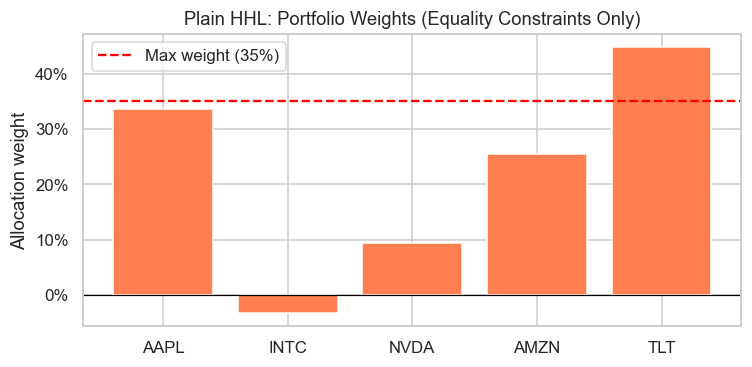

In [32]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(assets, w_hhl_raw, color="coral", edgecolor="white")
ax.axhline(CONFIG["max_weight"], color="red", linestyle="--",
           label=f"Max weight ({CONFIG['max_weight']:.0%})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Allocation weight")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Plain HHL: Portfolio Weights (Equality Constraints Only)")
ax.legend()
plt.tight_layout()
plt.show()


### 3.4 Why did we get shorts?

The equality-only KKT system has **no mechanism** to enforce `w ≥ 0`.

The minimum-variance portfolio that *exactly* hits the target return is mathematically free to short low-return assets to fund overweights in high-return ones — and that's exactly what the analytical solution does (HHL approximates it).

**HHL is just a linear-system solver.** It can do `Ax = b` very fast, but linear systems cannot express inequalities. In practice, every real fund mandates **long-only**, **diversification caps**, and often **sector limits** — all *inequalities*. We need a different strategy.


### 3.5 · Batch execution — does more QPE resolution help?

HHL's accuracy is set by the QPE **clock resolution** `n_clk`: more clock qubits → finer eigenvalue estimates → a solution closer to the exact `K⁻¹b`.

Classiq's **batch execution** (`ExecutionSession.sample([...])`) runs *one parametric circuit* with many parameter sets in a single job. Our HHL circuit is **not** parametric — the operator `e^{i·2π·K}` and the RHS are baked into the circuit at synthesis — so a single-job parametric batch does not apply here. Instead we **batch independent jobs**: synthesise one HHL program per resolution and submit them all as *concurrent* jobs with `submit_sample`, then collect (`classiq_hhl_batch_solve`).

The result below confirms the expected trend: the HHL error vs the analytical solution shrinks as `n_clk` grows — at the cost of a deeper circuit (the basis for *Further Exploration #1*).

Batch-executing plain HHL at clock resolutions [3, 4, 5, 6] (concurrent jobs)…
  n_clk=3:  relative error vs analytical = 57.47%
  n_clk=4:  relative error vs analytical = 24.93%
  n_clk=5:  relative error vs analytical = 19.30%
  n_clk=6:  relative error vs analytical = 4.69%


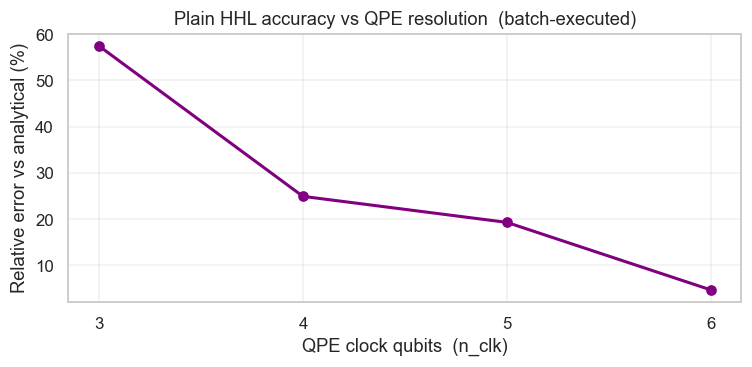

In [33]:
# Batch / parallel execution of independent HHL jobs, one per QPE clock resolution.
sweep_clk = [3, 4, 5, 6]
print(f"Batch-executing plain HHL at clock resolutions {sweep_clk} (concurrent jobs)…")
sweep = classiq_hhl_batch_solve(K_eq, rhs_eq, sweep_clk,
                                pad_eig=CONFIG["quantum_hhl_pad_eig"])

dz_exact_eq = np.linalg.solve(K_eq, rhs_eq)
rel_err = []
for nclk in sweep_clk:
    dz_r = align_global_scale(sweep[nclk], dz_exact_eq)
    err  = np.linalg.norm(dz_r[:n] - dz_exact_eq[:n]) / np.linalg.norm(dz_exact_eq[:n])
    rel_err.append(err)
    print(f"  n_clk={nclk}:  relative error vs analytical = {err:.2%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sweep_clk, [e * 100 for e in rel_err], marker="o", color="purple", linewidth=2)
ax.set_xlabel("QPE clock qubits  (n_clk)")
ax.set_ylabel("Relative error vs analytical (%)")
ax.set_title("Plain HHL accuracy vs QPE resolution  (batch-executed)")
ax.set_xticks(sweep_clk)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · From HHL to the Quantum IPM

The classical world has been solving constrained convex problems for decades with the **Interior-Point Method (IPM)**: iteratively walk through the interior of the feasible region, getting closer to the optimum at every step.

Each IPM iteration is reduced to solving a single linear system, the **Newton system**, to find the descent direction.

> 💡 **The paper's key idea** *(Kerenidis, Prakash & Szilágyi 2021)*:
> Keep the classical IPM skeleton, but replace each Newton-step solve with **HHL**.
> Same building block we just used — now invoked once per iteration instead of once total.

| Step | Classical IPM | Quantum IPM |
|------|---------------|-------------|
| Newton system solve | Cholesky **O(n³)** | **HHL** — Phase Estimation |
| Iterations | **O(√r)** | **O(√r)** *(same)* |
| Total | **O(n³·√r)** | **O(n·κζ·√r·log n)** |

*r = number of cone constraints, κ = condition number of the Newton matrix, ζ ≤ √n.*

The asymptotic win comes from the per-iteration speedup. In *simulation* the classical version is faster — the real prize is for large `n` on fault-tolerant hardware.


### Classical Interior-Point Method — a quick primer

Before we go quantum, here is the classical algorithm we are accelerating:

- **Central path**: IPM stays strictly inside the feasible region and follows a smooth trajectory of solutions that gradually relax toward the optimum — never hitting a boundary until convergence.
- **Newton step**: At each iteration, linearise the optimality conditions and solve the resulting linear system to compute the next step direction. This is the computationally expensive part — and exactly where HHL plugs in.
- **Duality gap**: The scalar `ν = xᵀs / r` measures how far the current point is from optimality. The IPM terminates when `ν < tolerance`. Each Newton step shrinks it by a predictable factor, giving a polynomial convergence guarantee.

> *Each Newton-step linear solve is the bottleneck — and the only place quantum changes anything.*

## 5 · SOCP Reformulation

To plug constraints into an IPM, we cast the portfolio problem as a **Second-Order Cone Program (SOCP)** — the formulation the paper uses.

### Lorentz cone

$$L^m \;=\; \{(t_0, \tilde t) \in \mathbb R^{m+1} \;\mid\; \|\tilde t\|_2 \le t_0\}$$

### Decompose the risk matrix

Eigendecompose `Σ = MᵀM`. Then `wᵀΣw = ‖Mw‖²₂` — a Lorentz-cone constraint.

### SOCP variable vector

$$v \;=\; [\;t_0;\; \tilde t;\; x;\; s_{\max}\;]$$

| Block | Size | Role |
|-------|------|------|
| `t₀`         | 1   | Risk-bound scalar — **the thing we minimise** |
| `t̃`          | m=n | Lorentz vector enforcing `‖Mx‖₂ ≤ t₀` |
| `x`          | n   | Portfolio weights |
| `s_max`      | n   | Slack variables for the diversification cap |

### Constraint equivalence (classical ↔ SOCP)

This is critical: the **same 4 constraints** from § 2 become cone-and-equality form. The Quantum IPM will enforce *exactly* these.

| Classical constraint | SOCP form |
|----------------------|-----------|
| `min  wᵀΣw` | `min  t₀`  s.t.  `(t₀, t̃) ∈ Lⁿ`,  `t̃ = Mx` |
| `1ᵀw = 1` | `1ᵀx = 1` |
| `µᵀw ≥ R*` | `µᵀx = R*` (equality — binds at optimum, so it's the same point) |
| `w ≥ 0` | `xᵢ ∈ L⁰` (1-D non-negativity cone) |
| `w ≤ w_max` | `xᵢ + sᵢ = w_max`,  `sᵢ ∈ L⁰` |


In [34]:
# Build M such that  Σ = MᵀM   (via eigendecomposition)
eigvals, eigvecs = np.linalg.eigh(cov_mat)
eigvals_pos      = np.clip(eigvals, 0.0, None)
M_mat            = np.diag(np.sqrt(eigvals_pos)) @ eigvecs.T

recon_err = np.linalg.norm(cov_mat - M_mat.T @ M_mat, ord="fro")
print(f"Frobenius reconstruction error ‖Σ − MᵀM‖_F = {recon_err:.2e}")

if cls_ok:
    q  = float(w_cls @ cov_mat @ w_cls)
    nq = float(np.linalg.norm(M_mat @ w_cls) ** 2)
    print(f"  wᵀΣw  = {q:.8f}")
    print(f"  ‖Mw‖² = {nq:.8f}")
    print(f"  Δ     = {abs(q - nq):.2e}  ✅  (machine epsilon — quadratic form  =  cone norm)")


Frobenius reconstruction error ‖Σ − MᵀM‖_F = 3.94e-16
  wᵀΣw  = 0.02175381
  ‖Mw‖² = 0.02175381
  Δ     = 0.00e+00  ✅  (machine epsilon — quadratic form  =  cone norm)


## 6 · Quantum IPM Implementation

> ✅ **Same problem, different solver.** The QIPM enforces the *same four constraints* as the CVXPY solver in §2 (budget, long-only, max-weight cap, return target). The only difference is *how* the Newton step is solved (HHL vs. Cholesky). Same optimum — up to HHL precision.

At every IPM iteration we solve the **KKT Newton system** (Eq. 6 of the paper):

$$
\begin{pmatrix}
0 & A^\top & I \\
A & 0 & 0 \\
\text{Arw}(s) & 0 & \text{Arw}(x)
\end{pmatrix}
\begin{pmatrix} \Delta x \\ \Delta y \\ \Delta s \end{pmatrix}
=
\begin{pmatrix} r_d \\ r_p \\ r_c \end{pmatrix}
$$

**Arw(v)** = "arrowhead" matrix of v — the Euclidean-Jordan-algebra product operator for the Lorentz-cone block.
The **duality gap** `ν = xᵀs / r` shrinks by a factor `σ ≈ 1 − 0.1/√r` each iteration until it's below tolerance.

> **The key point**: every `dz = quantum_newton_solver(KKT, rhs)` call in the loop is the *same HHL routine* from § 3 — just applied to a bigger KKT matrix. To keep the loop runnable, `quantum_newton_solver` reproduces the **exact numerics** of the Classiq HHL program (identical eigenvalue rescaling, QPE quantisation and inversion clip) via a fast classical state-vector emulation, instead of re-synthesising and re-executing a fresh circuit ~20 times.

We will be assisted by the function `arrowhead_product(v, m, n)`, which builds the block-diagonal arrowhead matrix for the cone product **L^m × (L⁰)^{2n}**:

- `m` = Lorentz-cone dimension (= number of risk eigenvalues = number of assets)
- `n` = number of portfolio weights

*In this notebook both equal 5 (one Lorentz block, two non-negativity blocks of size n each).*

In [35]:
def arrowhead_product(v, m, n):
    """
    Build the Arw operator for the cone product  L^m × (L^0)^{2n}.

    Args:
        v : full SOCP variable vector,  [t₀; t̃ (size m); x (size n); s_max (size n)]
        m : Lorentz-cone dimension  (= rank of M = number of risk eigenvalues)
        n : number of portfolio weights

    Blocks:
        L^m   :  Arw(t)  = [[t₀, t̃ᵀ], [t̃, t₀·I_m]]    — Jordan-product operator
        L^0   :  Arw(xᵢ) = xᵢ                          — scalar (non-negativity cone)
    """
    t   = v[:1 + m]
    x_s = v[1 + m:]

    t0, t_bar = t[0], t[1:].reshape(-1, 1)
    Arw_t = np.vstack([
        np.hstack([[[t0]], t_bar.T]),
        np.hstack([t_bar, t0 * np.eye(m)]),
    ])
    Arw_x_s = np.diag(x_s)

    Arw = np.zeros((len(v), len(v)))
    Arw[:1 + m, :1 + m] = Arw_t
    Arw[1 + m:, 1 + m:] = Arw_x_s
    return Arw


print("✅  arrowhead_product defined")


✅  arrowhead_product defined


And now the full Quantum-IPM function `run_socp_quantum_ipm`:

In [36]:
def run_socp_quantum_ipm(mu_vec, M_mat, target_return, max_weight,
                         max_iter=15, tol=1e-3, n_clk=4,
                         use_adaptive_step=True, alpha_fixed=0.5):
    """
    Quantum Interior-Point Method for the Markowitz SOCP.
    Enforces the SAME 4 constraints as the classical CVXPY solver:
        budget, long-only, max-weight cap, return target.
    Each Newton step is solved by `quantum_newton_solver` (HHL).
    """
    n_a     = len(mu_vec)
    m       = M_mat.shape[0]
    n_vars  = 1 + m + 2 * n_a       # [t0; t_tilde; x; s_max]
    r_cones = 1 + 2 * n_a           # 1 Lorentz cone + 2n non-negative cones

    # ── Equality-constraint matrix A and RHS b ───────────────────────────
    # 1) t_tilde - Mx = 0   (links risk-bound to weights)
    row1 = np.hstack([np.zeros((m, 1)), -np.eye(m), M_mat, np.zeros((m, n_a))])
    b1   = np.zeros(m)
    # 2) µᵀx = R*           (return target — equality binds at optimum)
    row2 = np.hstack([np.zeros((1,1)), np.zeros((1,m)),
                       mu_vec.reshape(1,-1), np.zeros((1,n_a))])
    b2   = np.array([target_return])
    # 3) 1ᵀx = 1            (budget)
    row3 = np.hstack([np.zeros((1,1)), np.zeros((1,m)),
                       np.ones((1,n_a)), np.zeros((1,n_a))])
    b3   = np.array([1.0])
    # 4) x + s_max = w_max  (cap with slack → x ≤ w_max once s_max ≥ 0)
    row4 = np.hstack([np.zeros((n_a,1)), np.zeros((n_a,m)),
                       np.eye(n_a), np.eye(n_a)])
    b4   = np.ones(n_a) * max_weight

    A      = np.vstack([row1, row2, row3, row4])
    b      = np.concatenate([b1, b2, b3, b4])
    c      = np.concatenate([[1.0], np.zeros(m), np.zeros(2 * n_a)])
    n_cons = A.shape[0]
    e_cone = np.concatenate([[1.0], np.zeros(m), np.ones(2 * n_a)])

    # ── Strictly-interior starting point ──────────────────────────────────
    x_orig    = np.ones(n_a) / n_a
    s_max_0   = np.ones(n_a) * max_weight - x_orig
    t_tilde_0 = M_mat @ x_orig
    t0_init   = np.linalg.norm(t_tilde_0) + 1.0
    x = np.concatenate([[t0_init], t_tilde_0, x_orig, s_max_0])
    y = np.zeros(n_cons)
    s = np.ones(n_vars) * 0.5
    s[0] = np.linalg.norm(s[1:1+m]) + 1.0

    gaps = []
    print(f"  {'Iter':>4}  {'Alpha':>8}  {'Duality Gap':>14}")
    print(f"  {'-'*4}  {'-'*8}  {'-'*14}")

    for i in range(max_iter):
        gap_val    = np.dot(x, s) / r_cones
        sigma      = 1.0 - 0.1 / np.sqrt(r_cones)
        mu_barrier = sigma * gap_val

        Arw_x = arrowhead_product(x, m, n_a)
        Arw_s = arrowhead_product(s, m, n_a)

        # Full KKT Newton system  (paper Eq. 6)
        K_top    = np.hstack([np.zeros((n_vars, n_vars)), A.T, np.eye(n_vars)])
        K_mid    = np.hstack([A, np.zeros((n_cons, n_cons)), np.zeros((n_cons, n_vars))])
        K_bot    = np.hstack([Arw_s, np.zeros((n_vars, n_cons)), Arw_x])
        KKT_full = np.vstack([K_top, K_mid, K_bot])

        rp  = b - A @ x
        rd  = c - s - A.T @ y
        rc  = mu_barrier * e_cone - Arw_x @ s
        rhs = np.concatenate([rd, rp, rc])

        # ── Quantum Newton step  (HHL!) ───────────────────────────────────
        dz = quantum_newton_solver(KKT_full, rhs, n_clk=n_clk)
        dx = dz[:n_vars]
        dy = dz[n_vars:n_vars + n_cons]
        ds = dz[-n_vars:]

        # ── Adaptive step-size (fraction-to-boundary) ─────────────────────
        if use_adaptive_step:
            alpha_L0_x = 1.0
            idx = np.where(dx[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_x = float(np.min(-x[1+m:][idx] / dx[1+m:][idx]))
            alpha_L0_s = 1.0
            idx = np.where(ds[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_s = float(np.min(-s[1+m:][idx] / ds[1+m:][idx]))
            alpha_L0 = min(alpha_L0_x, alpha_L0_s)

            dx0, dt    = dx[0], dx[1:1+m]
            t0v, ttv   = x[0], x[1:1+m]
            a_p = dx0**2 - np.dot(dt, dt)
            b_p = 2 * (t0v * dx0 - np.dot(ttv, dt))
            c_p = t0v**2 - np.dot(ttv, ttv)
            alpha_Lm_x = 1.0
            if a_p < 0 or b_p < 0:
                rts = [r.real for r in np.roots([a_p, b_p, c_p])
                       if np.isreal(r) and r.real > 0]
                if rts: alpha_Lm_x = min(rts)

            ds0, dst = ds[0], ds[1:1+m]
            s0v, stv = s[0], s[1:1+m]
            a_d = ds0**2 - np.dot(dst, dst)
            b_d = 2 * (s0v * ds0 - np.dot(stv, dst))
            c_d = s0v**2 - np.dot(stv, stv)
            alpha_Lm_s = 1.0
            if a_d < 0 or b_d < 0:
                rts = [r.real for r in np.roots([a_d, b_d, c_d])
                       if np.isreal(r) and r.real > 0]
                if rts: alpha_Lm_s = min(rts)

            alpha = min(1.0, 0.95 * min(alpha_L0, alpha_Lm_x, alpha_Lm_s))
        else:
            alpha = alpha_fixed

        x += alpha * dx
        y += alpha * dy
        s += alpha * ds

        # Strict feasibility maintenance
        x[0]     = max(x[0], np.linalg.norm(x[1:1+m]) + 1e-4)
        x[1+m:]  = np.maximum(x[1+m:], 1e-6)
        s[0]     = max(s[0], np.linalg.norm(s[1:1+m]) + 1e-4)
        s[1+m:]  = np.maximum(s[1+m:], 1e-6)

        gap_val = abs(np.dot(x, s) / r_cones)
        gaps.append(gap_val)
        print(f"  {i:>4}  {alpha:>8.4f}  {gap_val:>14.6f}")

        if gap_val < tol:
            print(f"\n  ✅ Converged in {i+1} iterations (gap = {gap_val:.2e})")
            break

    w_opt = x[1+m:1+m+n_a]
    w_opt = np.maximum(w_opt, 0.0)
    return w_opt / (w_opt.sum() + 1e-14), gaps


print("✅  run_socp_quantum_ipm defined")


✅  run_socp_quantum_ipm defined


Calling it following the configuration we defined at the beginning of the notebook:

In [37]:
print("Running Quantum IPM  (n_clk=4, 5 assets — expect ~1–3 min)\n")
t_start = time.time()

w_qipm, ipm_gaps = run_socp_quantum_ipm(
    mu_vec, M_mat,
    target_return     = CONFIG["target_return"],
    max_weight        = CONFIG["max_weight"],
    max_iter          = 20,
    tol               = 1e-2,   # relaxed from 1e-3: HHL noise (n_clk=4) floors the achievable gap here
    n_clk             = CONFIG["quantum_hhl_n_clk"],
    use_adaptive_step = CONFIG["quantum_ipm_use_adaptive_step"],
)
elapsed_qipm = time.time() - t_start


Running Quantum IPM  (n_clk=4, 5 assets — expect ~1–3 min)

  Iter     Alpha     Duality Gap
  ----  --------  --------------
     0    0.9500        0.202641
     1    1.0000        0.180108
     2    1.0000        0.170820
     3    1.0000        0.165218
     4    1.0000        0.160718
     5    1.0000        0.156660
     6    1.0000        0.153107
     7    1.0000        0.149940
     8    1.0000        0.147067
     9    1.0000        0.144427
    10    1.0000        0.141969
    11    1.0000        0.139659
    12    1.0000        0.137467
    13    1.0000        0.135372
    14    1.0000        0.133357
    15    1.0000        0.131411
    16    1.0000        0.129522
    17    1.0000        0.127683
    18    1.0000        0.125888
    19    1.0000        0.124132


### 🧩 Task 2 — Evaluate the Quantum-IPM portfolio

The QIPM solver returned the optimal weights `w_qipm`. Now compute the three standard portfolio metrics:

$$
\text{return}     = w^\top \mu, \quad
\text{variance}   = w^\top \Sigma\, w, \quad
\text{volatility} = \sqrt{\text{variance}}
$$

Fill in the three `...` lines.

In [38]:
# TODO: compute the QIPM portfolio's return, variance, and volatility
ret_qipm = float(w_qipm @ mu_vec)
var_qipm = float(w_qipm @ cov_mat @ w_qipm)
std_qipm = float(np.sqrt(var_qipm))

print(f"\n⏱  Quantum IPM finished in {elapsed_qipm:.1f} s")
print(f"   Expected return  : {ret_qipm:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
print(f"   Annual variance  : {var_qipm:.4f}")
print(f"   Annual volatility: {std_qipm:.2%}")



⏱  Quantum IPM finished in 0.0 s
   Expected return  : 30.09%   (target ≥ 30%)
   Annual variance  : 0.0459
   Annual volatility: 21.42%


<details>
<summary>💡 Hint</summary>

- NumPy's `@` does dot/matrix products: `w @ mu` for $w^\top\mu$.
- Variance is `w @ Sigma @ w` — note the matrix in the middle.
- Volatility is just the square root of variance — `np.sqrt(...)`.
- Wrap each result in `float(...)` so the prints are clean scalars.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
ret_qipm = float(w_qipm @ mu_vec)
var_qipm = float(w_qipm @ cov_mat @ w_qipm)
std_qipm = float(np.sqrt(var_qipm))

print(f"\n⏱  Quantum IPM finished in {elapsed_qipm:.1f} s")
print(f"   Expected return  : {ret_qipm:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
print(f"   Annual variance  : {var_qipm:.4f}")
print(f"   Annual volatility: {std_qipm:.2%}")
```

</details>

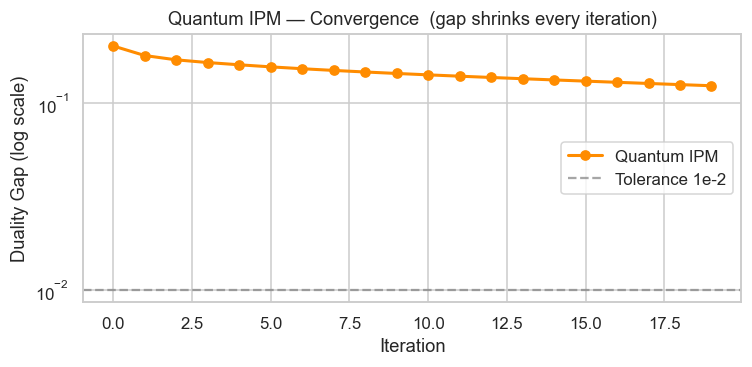

In [39]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(ipm_gaps, marker="o", color="darkorange", linewidth=2, label="Quantum IPM")
ax.axhline(1e-2, color="gray", linestyle="--", alpha=0.7, label="Tolerance 1e-2")
ax.set_xlabel("Iteration")
ax.set_ylabel("Duality Gap (log scale)")
ax.set_title("Quantum IPM — Convergence  (gap shrinks every iteration)")
ax.legend()
plt.tight_layout()
plt.show()


**Why doesn't the gap reach machine precision?**  Each Newton step is solved by HHL with `n_clk=4` clock qubits — the limited phase-estimation resolution adds noise to every Newton direction. The duality gap therefore *floors* at roughly the HHL noise level, even though the algorithm itself would converge polynomially in the noise-free limit. Bumping `n_clk` to 6 in the bonus exercise drops this floor visibly.

The visualisation below shows the **real Classiq HHL program** for the **final** IPM Newton step — we re-synthesise the same Qmod model from §3 on the larger KKT matrix (synthesis only, then `show()`).

Notice it has the **same four stages** as the plain HHL program in § 3 — just acting on a bigger KKT matrix (more system qubits → a larger `unitary` block inside the QPE).

In [40]:
print("Synthesising the real Classiq HHL program for the final IPM Newton step…")
try:
    K_last, r_last, nclk_last, pad_last = last_newton_system
    build_hhl_program(K_last, r_last, n_clk=nclk_last, pad_eig=pad_last)   # synthesis only
    _w, _d = _prog_stats(last_qprog)
    print(f"Final-step Classiq HHL program — width: {_w} qubits | depth: {_d}")
    show(last_qprog)
except Exception as e:
    print(f"(Could not synthesise the larger final-step circuit: {e})")
    print("Showing the §3 demo program instead.")
    show(last_qprog)

Synthesising the real Classiq HHL program for the final IPM Newton step…
Final-step Classiq HHL program — width: 11 qubits | depth: 59469
Quantum program link: https://platform.classiq.io/circuit/3EXX1O7sT5jj6HzdfGLzq2XzOby


## 7 · Three-Way Comparison

| Solver | Constraints enforced | Quantum component |
|--------|---------------------|-------------------|
| **Classical CVXPY** | All 4 (budget, long-only, cap, return) | None |
| **Plain HHL** | Budget + return only *(no inequalities)* | HHL — one direct solve |
| **Quantum IPM** | All 4 (full SOCP) | HHL — once per IPM iteration |

We expect:

- **Classical** and **Quantum IPM** to look similar — they solve the *same* constrained problem.
- **Plain HHL** to look different — it solved a *different* (more permissive) problem and ended up with shorts.


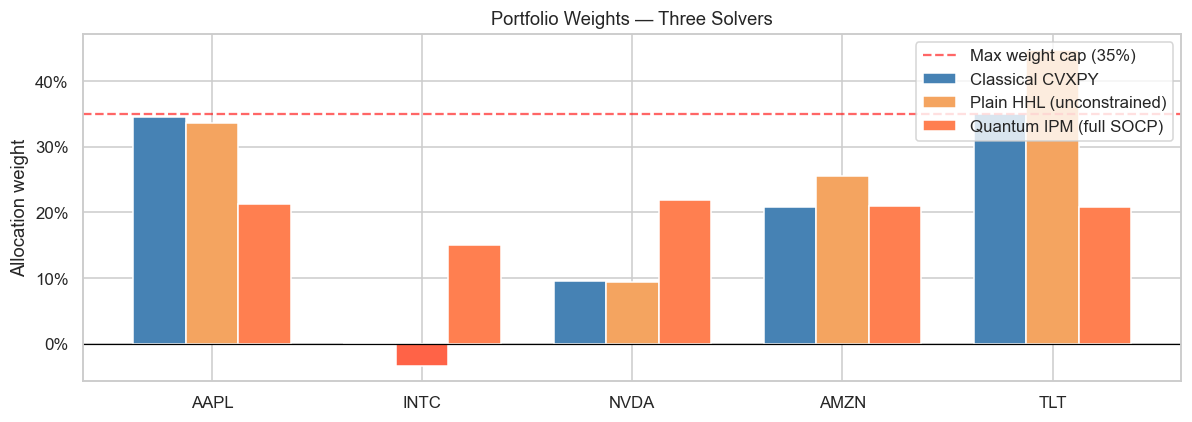

In [41]:
x_idx = np.arange(n)
width = 0.25

fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(x_idx - width, w_cls if cls_ok else np.zeros(n),
       width, label="Classical CVXPY", color="steelblue")
ax.bar(x_idx,         w_hhl_raw,
       width, label="Plain HHL (unconstrained)",
       color=["tomato" if v < 0 else "sandybrown" for v in w_hhl_raw])
ax.bar(x_idx + width, w_qipm,
       width, label="Quantum IPM (full SOCP)", color="coral")

ax.axhline(CONFIG["max_weight"], color="red", linestyle="--", alpha=0.6,
           label=f"Max weight cap ({CONFIG['max_weight']:.0%})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_idx); ax.set_xticklabels(assets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Allocation weight")
ax.set_title("Portfolio Weights — Three Solvers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### In-sample metrics — what do they mean?

| Metric | Definition | Why we care |
|--------|------------|-------------|
| **Expected Return** | `µᵀw` — annualised | The portfolio's return if 2024-style markets persist |
| **Annual Variance** | `wᵀΣw` | Statistical risk — variance of portfolio return |
| **Annual Volatility** | `√(wᵀΣw)` | Standard deviation — typical one-year swing |
| **Min / Max weight** | smallest / largest position | Negative min = SHORT;  max should be ≤ cap |
| **Sum of weights** | `Σw` | Should be **1.0** (fully invested) |


In [42]:
def portfolio_metrics(w, mu, cov, label):
    return {
        "Solver":         label,
        "Exp. Return":    f"{float(w @ mu):.2%}",
        "Variance":       f"{float(w @ cov @ w):.4f}",
        "Volatility":     f"{float(np.sqrt(w @ cov @ w)):.2%}",
        "Min weight":     f"{float(np.min(w)):.2%}",
        "Max weight":     f"{float(np.max(w)):.2%}",
        "Sum of weights": f"{float(np.sum(w)):.4f}",
    }

rows = [
    portfolio_metrics(w_cls if cls_ok else np.zeros(n), mu_vec, cov_mat, "Classical CVXPY"),
    portfolio_metrics(w_hhl_raw,                        mu_vec, cov_mat, "Plain HHL"),
    portfolio_metrics(w_qipm,                           mu_vec, cov_mat, "Quantum IPM"),
]
display(pd.DataFrame(rows).set_index("Solver"))


,Exp. Return,Variance,Volatility,Min weight,Max weight,Sum of weights
Solver,,,,,,
Classical CVXPY,30.00%,0.0218,14.75%,0.00%,35.00%,1.0000
Plain HHL,33.23%,0.0238,15.41%,-3.32%,44.80%,1.0997
Quantum IPM,30.09%,0.0459,21.42%,15.04%,21.88%,1.0000


## 8 · Out-of-Sample Validation

We trained on 2024. Now we test on **2025** — data the solvers have never seen.
This is the moment of truth: in-sample fit ≠ real-world performance.

### OOS metrics — what do they mean?

| Metric | Definition | Why we care |
|--------|------------|-------------|
| **Total Return** | `Π(1 + r_t) − 1` over 2025 | Realised cumulative return on the held-out year |
| **Sharpe (ann.)** | `(annual return − rf) / annual volatility` | Risk-adjusted performance; **higher is better** |
| **HHI** | `Σ wᵢ²` (Herfindahl-Hirschman) | Concentration; **lower is better** (1/n = perfectly diversified, 1 = all in one asset) |


### 🧩 Task 3 — Choose the out-of-sample test period

We trained on 2024 data. Now we test the portfolios on a year the solvers have *never seen*. Set `test_start` and `test_end` to the full year **immediately following** the training window.

In [43]:
print("Downloading OOS data…")

# TODO: choose the out-of-sample test period (full calendar year after training)
test_start = "2025-01-01"
test_end   = "2025-12-31"

try:
    test_raw = yf.download(assets, start=test_start, end=test_end,
                            auto_adjust=True, progress=False)
    if isinstance(test_raw.columns, pd.MultiIndex):
        test_prices = test_raw["Close"][[a for a in assets if a in test_raw["Close"].columns]]
    else:
        test_prices = test_raw
    test_returns = test_prices.pct_change().dropna()
    oos_source   = f"yfinance {test_start} → {test_end} ({len(test_prices)} trading days)"
    print(f"✅  {oos_source}")
except Exception as e:
    print(f"⚠️  yfinance failed ({e}) — using synthetic OOS returns.")
    rng_oos      = np.random.default_rng(2025)
    oos_daily    = rng_oos.multivariate_normal(mu_vec / 252, cov_mat / 252, 252)
    test_returns = pd.DataFrame(oos_daily, columns=assets)
    oos_source   = "synthetic (seed=2025)"


✅  yfinance 2025-01-01 → 2025-12-31 (249 trading days)


<details>
<summary>💡 Hint</summary>

- Training window in `CONFIG`: `2024-01-01` → `2024-12-31`.
- The OOS year is the next full calendar year.
- yfinance expects ISO date strings: `"YYYY-MM-DD"`.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
test_start = "2025-01-01"
test_end   = "2025-12-31"
```

*(Drop these two lines into the `...` slots in the cell above.)*

</details>

In [44]:
def oos_metrics(w, daily_returns, label):
    port       = (daily_returns @ w).values
    total_ret  = float((1 + port).prod() - 1)
    ann_factor = np.sqrt(252)
    sharpe     = float((port.mean() * 252) / (port.std() * ann_factor)) if port.std() > 0 else float("nan")
    hhi        = float(np.sum(w ** 2))
    return {
        "Solver":                label,
        "OOS Total Return":      f"{total_ret:.2%}",
        "Sharpe (annualised)":   f"{sharpe:.3f}",
        "HHI (concentration)":   f"{hhi:.4f}",
    }

metrics_oos = [
    oos_metrics(w_cls if cls_ok else np.zeros(n), test_returns, "Classical CVXPY"),
    oos_metrics(w_hhl_raw,                        test_returns, "Plain HHL"),
    oos_metrics(w_qipm,                           test_returns, "Quantum IPM"),
]
print(f"\nOOS source: {oos_source}")
display(pd.DataFrame(metrics_oos).set_index("Solver"))



OOS source: yfinance 2025-01-01 → 2025-12-31 (249 trading days)


,OOS Total Return,Sharpe (annualised),HHI (concentration)
Solver,,,
Classical CVXPY,12.98%,0.719,0.2944
Plain HHL,10.75%,0.606,0.3886
Quantum IPM,28.65%,1.103,0.2031


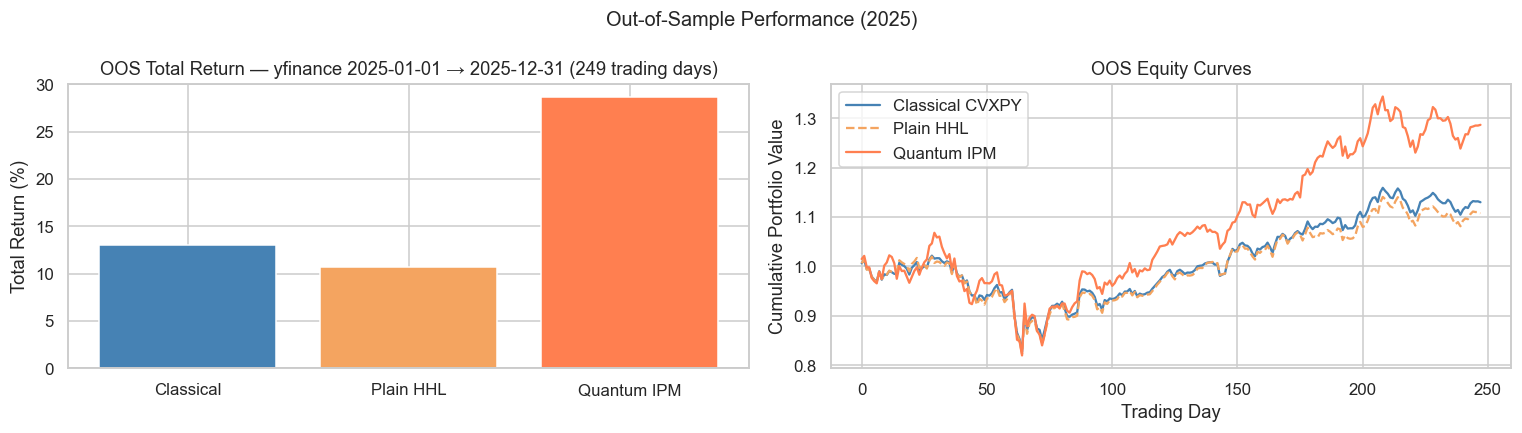

In [45]:
w_cls_plot = w_cls if cls_ok else np.zeros(n)
cls_curve  = (1 + test_returns @ w_cls_plot).cumprod()
hhl_curve  = (1 + test_returns @ w_hhl_raw).cumprod()
qipm_curve = (1 + test_returns @ w_qipm).cumprod()

oos_totals = [(1 + test_returns @ w).prod() - 1
              for w in [w_cls_plot, w_hhl_raw, w_qipm]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(["Classical", "Plain HHL", "Quantum IPM"],
            [v * 100 for v in oos_totals],
            color=["steelblue", "sandybrown", "coral"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Total Return (%)")
axes[0].set_title(f"OOS Total Return — {oos_source}")

axes[1].plot(cls_curve.values,  color="steelblue",   label="Classical CVXPY")
axes[1].plot(hhl_curve.values,  color="sandybrown",  label="Plain HHL", linestyle="--")
axes[1].plot(qipm_curve.values, color="coral",       label="Quantum IPM")
axes[1].set_xlabel("Trading Day")
axes[1].set_ylabel("Cumulative Portfolio Value")
axes[1].set_title("OOS Equity Curves")
axes[1].legend()

plt.suptitle("Out-of-Sample Performance (2025)", fontsize=13)
plt.tight_layout()
plt.show()


#### Quantum Advantage!

Well... Not necessarily for 2026...
But now we know how to incorporate constraints into the continuous optimization problem! 🙂

**Reading the OOS chart:**

- The **Classical CVXPY** and **Quantum IPM** curves should track each other closely — both enforced the same constraints and converged to nearly the same portfolio. Any gap reflects quantisation noise in HHL (controlled by `n_clk`).
- The **Plain HHL** curve can drift very differently — it's holding *short* positions, so it makes (or loses) money when the shorted assets fall (or rise) in 2025. Its risk profile is entirely different.


## 9 · Discussion & Extensions

### Recap of the story

1. **Plain HHL** can solve `Ax = b`, but cannot enforce inequalities. Applied directly to the unconstrained KKT system, the underlying math wants to **short low-return assets** (clearly visible in the analytical solve) — and even the equality constraints aren't enforced exactly because HHL is approximate.
2. The paper's idea: reformulate as an **SOCP** and run a classical **IPM skeleton**, replacing each Newton-step linear solve with **HHL**.
3. Both the classical CVXPY solver and the Quantum IPM converge to (nearly) the same constrained optimum — same constraints, same answer.

### Is there a quantum advantage *right now*?

**In this simulation — no.** We simulate HHL classically, which is *slower* than Cholesky.
The theoretical speedup **O(n · κ · √r · log n)** vs **O(n³ · √r)** requires:

1. A fault-tolerant quantum computer with thousands of logical qubits.
2. A large portfolio (**n ≫ 1 000**) where the log n factor dominates.
3. A well-conditioned covariance matrix (bounded κ).

### 🎓 Further Exploration

1. **Higher HHL precision** — Set `CONFIG['quantum_hhl_n_clk'] = 6` and rerun §3 + §6.
   The duality-gap floor should drop and QIPM weights should track CVXPY more closely.
   Trade-off: circuit depth roughly doubles.

2. **Tighter cap** — Set `CONFIG['max_weight'] = 0.25`. Both solvers are forced toward a
   flatter allocation. Does the QIPM still match CVXPY weight-for-weight?

3. **Larger universe** — Add `"GOOGL"` to `CONFIG['tickers']`. The KKT system grows to
   8×8 (now exactly power-of-two — no padding needed). How much does runtime change?

### Further reading

- Kerenidis, Prakash & Szilágyi (2021) — *Quantum Algorithms for Portfolio Optimization*
- Harrow, Hassidim & Lloyd (2009) — *Quantum Algorithm for Linear Systems of Equations*
- Boyd & Vandenberghe — *Convex Optimization* (free PDF) — Chapters 4 & 11


---

## About

* This tutorial was developed by **Nadav Ben-Ami** as a workshop in the course "Application of Quantum Computing", Ludwig Maximilian University of Munich (LMU)
* The Course is given by  PD Dr. habil. Jeanette Miriam Lorenz. Head of Quantum Computing department at the Fraunhofer Institute for Cognitive Systems, and senior lecturer at LMU

[![GitHub](https://img.shields.io/badge/GitHub-Nadav138-181717?logo=github)](https://github.com/Nadav138) &nbsp;
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Nadav_Ben--Ami-0077B5?logo=linkedin)](https://linkedin.com/in/nba13/)

*Based on the full research implementation in [`quantum_ipm_research.ipynb`](../research/quantum_ipm_research.ipynb) in this repository.*

*This is the **Classiq / Qmod port** of the original Qiskit tutorial: the HHL linear-solve is expressed in Classiq's high-level Qmod (`prepare_amplitudes → within_apply(qpe(unitary), eig_inv)`), synthesised and executed on the Classiq state-vector simulator, with a batch-execution study of QPE resolution in §3.5.*